In [1]:
from pathlib import Path
import joblib

DATA_DIR = Path("data")

checkpoint_path = (
    DATA_DIR / "GSE25055_pre_lasso.joblib"
)

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: "
        f"{checkpoint_path.resolve()}"
    )

checkpoint = joblib.load(
    checkpoint_path
)

X = checkpoint["X"]
y = checkpoint["y"]
gene_annotation = checkpoint["gene_annotation"]

y.name = "Response_Label"

print("Dataset:", checkpoint["dataset_id"])
print("Label mapping:", checkpoint["label_mapping"])

print("X:", X.shape)
print("y:", y.shape)

print("\nClass distribution:")
print(y.value_counts().sort_index())

Dataset: GSE25055
Label mapping: {'RD': 0, 'pCR': 1}
X: (306, 22283)
y: (306,)

Class distribution:
Response_Label
0    249
1     57
Name: count, dtype: int64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42

assert len(X) == len(y)
assert X.index.equals(y.index)
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0
assert set(y.unique()) == {0, 1}

print("Checkpoint data are valid.")

Checkpoint data are valid.


In [3]:
outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


def create_lasso_pipeline():
    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "lasso",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ])


parameter_grid = {
    # Smaller C = stronger regularization
    # Larger C = weaker regularization
    "lasso__C": np.logspace(-4, 2, 9),

    # Test whether class weighting improves the model
    "lasso__class_weight": [
        None,
        "balanced"
    ]
}

print("Values of C:")
print(parameter_grid["lasso__C"])

Values of C:
[1.00000000e-04 5.62341325e-04 3.16227766e-03 1.77827941e-02
 1.00000000e-01 5.62341325e-01 3.16227766e+00 1.77827941e+01
 1.00000000e+02]


In [4]:
fold_metrics = []
selection_records = []
selected_sets = {}

oof_probability = pd.Series(
    np.nan,
    index=y.index,
    name="pCR_probability"
)

oof_prediction = pd.Series(
    pd.NA,
    index=y.index,
    dtype="Int64",
    name="predicted_response"
)

feature_names = X.columns.to_numpy()


for fold, (train_indices, validation_indices) in enumerate(
    outer_cv.split(X, y),
    start=1
):
    print(f"\nStarting outer fold {fold}/10")

    X_train = X.iloc[train_indices]
    X_validation = X.iloc[validation_indices]

    y_train = y.iloc[train_indices]
    y_validation = y.iloc[validation_indices]

    search = GridSearchCV(
        estimator=create_lasso_pipeline(),
        param_grid=parameter_grid,
        scoring="average_precision",
        cv=inner_cv,
        refit=True,
        n_jobs=-1
    )

    # Scaling, parameter selection and LASSO
    # are fitted only using the outer training fold
    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    validation_probability = (
        best_model.predict_proba(X_validation)[:, 1]
    )

    validation_prediction = (
        best_model.predict(X_validation)
    )

    oof_probability.iloc[
        validation_indices
    ] = validation_probability

    oof_prediction.iloc[
        validation_indices
    ] = validation_prediction

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        validation_prediction,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    coefficients = (
        best_model
        .named_steps["lasso"]
        .coef_
        .ravel()
    )

    selected_mask = (
        np.abs(coefficients) > 1e-10
    )

    selected_probes = set(
        feature_names[selected_mask]
    )

    selected_sets[fold] = selected_probes

    fold_metrics.append({
        "fold": fold,
        "training_patients": len(train_indices),
        "validation_patients": len(validation_indices),
        "best_C": search.best_params_["lasso__C"],
        "best_class_weight": str(
            search.best_params_["lasso__class_weight"]
        ),
        "selected_probes": len(selected_probes),
        "roc_auc": roc_auc_score(
            y_validation,
            validation_probability
        ),
        "average_precision": average_precision_score(
            y_validation,
            validation_probability
        ),
        "accuracy": accuracy_score(
            y_validation,
            validation_prediction
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            validation_prediction
        ),
        "f1": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "sensitivity": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "specificity": specificity
    })

    for probe_id, coefficient in zip(
        feature_names[selected_mask],
        coefficients[selected_mask]
    ):
        selection_records.append({
            "fold": fold,
            "PROBEID": probe_id,
            "coefficient": coefficient
        })

    print("Best parameters:", search.best_params_)
    print("Selected probes:", len(selected_probes))

    print(
        "ROC-AUC:",
        round(fold_metrics[-1]["roc_auc"], 3)
    )

    print(
        "Average precision:",
        round(
            fold_metrics[-1]["average_precision"],
            3
        )
    )


Starting outer fold 1/10


d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'lasso__C': np.float64(0.1), 'lasso__class_weight': None}
Selected probes: 74
ROC-AUC: 0.78
Average precision: 0.442

Starting outer fold 2/10


d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'lasso__C': np.float64(100.0), 'lasso__class_weight': 'balanced'}
Selected probes: 750
ROC-AUC: 0.693
Average precision: 0.449

Starting outer fold 3/10


...

Best parameters: {'lasso__C': np.float64(100.0), 'lasso__class_weight': 'balanced'}
Selected probes: 757
ROC-AUC: 0.632
Average precision: 0.49

Starting outer fold 9/10


d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'lasso__C': np.float64(100.0), 'lasso__class_weight': None}
Selected probes: 700
ROC-AUC: 0.84
Average precision: 0.648

Starting outer fold 10/10


d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\diplom-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'lasso__C': np.float64(0.1), 'lasso__class_weight': 'balanced'}
Selected probes: 87
ROC-AUC: 0.729
Average precision: 0.381


In [5]:
cv_results = pd.DataFrame(fold_metrics)

display(cv_results)

metric_columns = [
    "roc_auc",
    "average_precision",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "sensitivity",
    "specificity"
]

cv_summary = (
    cv_results[metric_columns]
    .agg(["mean", "std"])
    .T
    .rename(
        columns={
            "mean": "Mean",
            "std": "Standard deviation"
        }
    )
)

print("Cross-validation summary:")
display(cv_summary)

,fold,training_patients,validation_patients,best_C,best_class_weight,selected_probes,roc_auc,average_precision,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity
0,1,275,31,0.1,None,74,0.780000,0.441880,0.774194,0.543333,0.222222,0.333333,0.166667,0.920000
1,2,275,31,100.0,balanced,750,0.693333,0.449255,0.806452,0.563333,0.250000,0.500000,0.166667,0.960000
2,3,275,31,0.1,None,77,0.666667,0.391385,0.741935,0.460000,0.000000,0.000000,0.000000,0.920000
3,4,275,31,100.0,balanced,726,0.473333,0.339628,0.741935,0.523333,0.200000,0.250000,0.166667,0.880000
4,5,275,31,100.0,None,661,0.940000,0.682937,0.870968,0.730000,0.600000,0.750000,0.500000,0.960000
5,6,275,31,100.0,balanced,777,0.866667,0.620202,0.806452,0.563333,0.250000,0.500000,0.166667,0.960000
6,7,276,30,100.0,None,645,0.872000,0.490909,0.833333,0.580000,0.285714,0.500000,0.200000,0.960000
7,8,276,30,100.0,balanced,757,0.632000,0.490370,0.833333,0.740000,0.545455,0.500000,0.600000,0.880000
8,9,276,30,100.0,None,700,0.840000,0.647619,0.833333,0.580000,0.285714,0.500000,0.200000,0.960000
9,10,276,30,0.1,balanced,87,0.729167,0.381498,0.766667,0.729167,0.533333,0.444444,0.666667,0.791667


Cross-validation summary:


,Mean,Standard deviation
roc_auc,0.749317,0.139303
average_precision,0.493568,0.118781
accuracy,0.800860,0.043417
balanced_accuracy,0.601250,0.097380
f1,0.317244,0.186541
precision,0.427778,0.198243
sensitivity,0.283333,0.221805
specificity,0.919167,0.055440


In [6]:
assert oof_probability.notna().all()
assert oof_prediction.notna().all()

oof_prediction = oof_prediction.astype(int)

tn, fp, fn, tp = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1]
).ravel()

overall_specificity = tn / (tn + fp)

overall_results = pd.Series({
    "ROC-AUC": roc_auc_score(
        y,
        oof_probability
    ),
    "Average precision": average_precision_score(
        y,
        oof_probability
    ),
    "Accuracy": accuracy_score(
        y,
        oof_prediction
    ),
    "Balanced accuracy": balanced_accuracy_score(
        y,
        oof_prediction
    ),
    "F1": f1_score(
        y,
        oof_prediction,
        zero_division=0
    ),
    "Precision": precision_score(
        y,
        oof_prediction,
        zero_division=0
    ),
    "Sensitivity": recall_score(
        y,
        oof_prediction,
        zero_division=0
    ),
    "Specificity": overall_specificity
})

print("Overall out-of-fold performance:")
display(
    overall_results.to_frame("Value")
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y,
        oof_prediction,
        labels=[0, 1]
    )
)

Overall out-of-fold performance:


,Value
ROC-AUC,0.726767
Average precision,0.407587
Accuracy,0.800654
Balanced accuracy,0.600190
F1,0.344086
Precision,0.444444
Sensitivity,0.280702
Specificity,0.919679


Confusion matrix:
[[229  20]
 [ 41  16]]


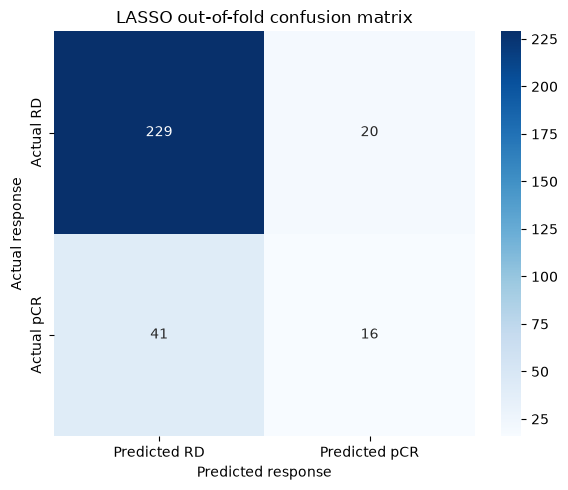

In [7]:
confusion = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1]
)

confusion_table = pd.DataFrame(
    confusion,
    index=[
        "Actual RD",
        "Actual pCR"
    ],
    columns=[
        "Predicted RD",
        "Predicted pCR"
    ]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "LASSO out-of-fold confusion matrix"
)
plt.ylabel("Actual response")
plt.xlabel("Predicted response")
plt.tight_layout()
plt.show()

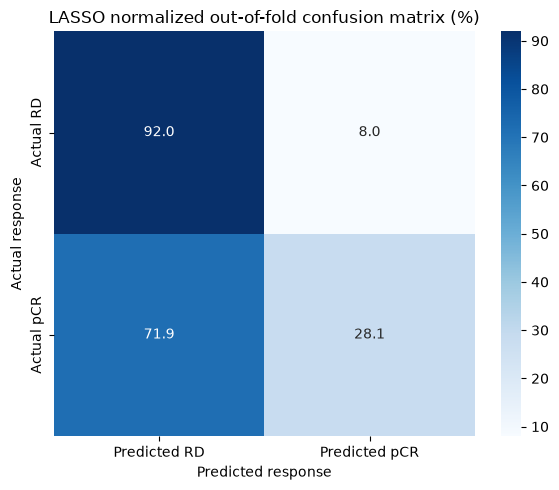

In [8]:
normalized_confusion = (
    confusion
    / confusion.sum(axis=1, keepdims=True)
)

normalized_table = pd.DataFrame(
    normalized_confusion * 100,
    index=[
        "Actual RD",
        "Actual pCR"
    ],
    columns=[
        "Predicted RD",
        "Predicted pCR"
    ]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    normalized_table,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "LASSO normalized out-of-fold confusion matrix (%)"
)
plt.ylabel("Actual response")
plt.xlabel("Predicted response")
plt.tight_layout()
plt.show()

In [9]:
selected_by_fold = pd.DataFrame(
    selection_records
)

if selected_by_fold.empty:
    raise RuntimeError(
        "LASSO selected no probes in any fold."
    )

feature_stability = (
    selected_by_fold
    .groupby("PROBEID")
    .agg(
        selected_folds=(
            "fold",
            "nunique"
        ),
        mean_coefficient=(
            "coefficient",
            "mean"
        ),
        mean_absolute_coefficient=(
            "coefficient",
            lambda values: values.abs().mean()
        )
    )
    .reset_index()
)

feature_stability["selection_frequency"] = (
    feature_stability["selected_folds"] / 10
)

feature_stability = (
    feature_stability
    .merge(
        gene_annotation,
        on="PROBEID",
        how="left"
    )
    .sort_values(
        [
            "selection_frequency",
            "mean_absolute_coefficient"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    feature_stability.head(50)
)

,PROBEID,selected_folds,mean_coefficient,mean_absolute_coefficient,selection_frequency,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS
1056,212431_at,10,-0.289665,0.289665,1.0,HMGXB3,HMG box domain containing 3,22993,1,Unique
260,204012_s_at,10,-0.218137,0.218137,1.0,LCMT2,leucine carboxyl methyltransferase 2,9836,1,Unique
474,206373_at,10,0.204937,0.204937,1.0,ZIC1,Zic family member 1,7545,1,Unique
1193,214231_s_at,10,-0.183230,0.183230,1.0,VWA8,von Willebrand factor A domain containing 8,23078,1,Unique
1279,215233_at,10,0.181315,0.181315,1.0,JMJD6,jumonji domain containing 6,23210,1,Unique
988,211620_x_at,10,0.180556,0.180556,1.0,LOC100506403 /// LOC101928269 /// RUNX1,uncharacterized LOC100506403 /// uncharacteriz...,861 /// 100506403 /// 101928269,3,Multiple genes
1251,214960_at,10,0.176587,0.176587,1.0,API5,apoptosis inhibitor 5,8539,1,Unique
715,208854_s_at,10,0.160484,0.160484,1.0,STK24,serine/threonine kinase 24,8428,1,Unique
353,205163_at,10,-0.149564,0.149564,1.0,MYLPF,"myosin light chain, phosphorylatable, fast ske...",29895,1,Unique
1680,219051_x_at,10,-0.147432,0.147432,1.0,METRN,"meteorin, glial cell differentiation regulator",79006,1,Unique


In [10]:
feature_stability.to_excel("results/lasso_feature_stability.xlsx", index=False)

ModuleNotFoundError: No module named 'openpyxl'

In [11]:
feature_stability = (
    feature_stability
    .sort_values(
        ["selection_frequency", "mean_absolute_coefficient"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(feature_stability.head(30))

,PROBEID,selected_folds,mean_coefficient,mean_absolute_coefficient,selection_frequency,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS
0,212431_at,10,-0.289665,0.289665,1.0,HMGXB3,HMG box domain containing 3,22993,1,Unique
1,204012_s_at,10,-0.218137,0.218137,1.0,LCMT2,leucine carboxyl methyltransferase 2,9836,1,Unique
2,206373_at,10,0.204937,0.204937,1.0,ZIC1,Zic family member 1,7545,1,Unique
3,214231_s_at,10,-0.183230,0.183230,1.0,VWA8,von Willebrand factor A domain containing 8,23078,1,Unique
4,215233_at,10,0.181315,0.181315,1.0,JMJD6,jumonji domain containing 6,23210,1,Unique
5,211620_x_at,10,0.180556,0.180556,1.0,LOC100506403 /// LOC101928269 /// RUNX1,uncharacterized LOC100506403 /// uncharacteriz...,861 /// 100506403 /// 101928269,3,Multiple genes
6,214960_at,10,0.176587,0.176587,1.0,API5,apoptosis inhibitor 5,8539,1,Unique
7,208854_s_at,10,0.160484,0.160484,1.0,STK24,serine/threonine kinase 24,8428,1,Unique
8,205163_at,10,-0.149564,0.149564,1.0,MYLPF,"myosin light chain, phosphorylatable, fast ske...",29895,1,Unique
9,219051_x_at,10,-0.147432,0.147432,1.0,METRN,"meteorin, glial cell differentiation regulator",79006,1,Unique


In [12]:
print("Number of probes in stability table:", len(feature_stability))

print(
    "\nDuplicate PROBEIDs:",
    feature_stability["PROBEID"].duplicated().sum()
)

print("\nDistribution by number of selected folds:")
print(
    feature_stability["selected_folds"]
    .value_counts()
    .sort_index(ascending=False)
)

assert feature_stability["PROBEID"].is_unique
assert feature_stability["selected_folds"].between(1, 10).all()
assert feature_stability["selection_frequency"].between(0, 1).all()

Number of probes in stability table: 2015

Duplicate PROBEIDs: 0

Distribution by number of selected folds:
selected_folds
10     14
9      23
8      35
7      86
6      88
5     115
4     148
3     226
2     372
1     908
Name: count, dtype: int64


In [13]:
from pathlib import Path

import pandas as pd

from openpyxl.styles import (
    Alignment,
    Font,
    PatternFill
)
from openpyxl.utils import get_column_letter


def export_lasso_results_to_excel(
    feature_stability,
    cv_results,
    cv_summary,
    output_path="results/GSE25055_lasso_results.xlsx"
):
    """
    Export LASSO feature stability and cross-validation
    results to one formatted Excel workbook.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Clean the old pandas index and sort the table
    all_features = (
        feature_stability
        .copy()
        .sort_values(
            [
                "selection_frequency",
                "mean_absolute_coefficient"
            ],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    # Add a human-readable direction
    all_features["coefficient_direction"] = (
        all_features["mean_coefficient"]
        .apply(
            lambda value: (
                "Towards pCR"
                if value > 0
                else "Towards RD"
                if value < 0
                else "No direction"
            )
        )
    )

    # Particularly stable probes
    stable_80 = (
        all_features[
            all_features["selection_frequency"] >= 0.8
        ]
        .copy()
        .reset_index(drop=True)
    )

    selected_10_of_10 = (
        all_features[
            all_features["selected_folds"] == 10
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Make the CV summary index an ordinary Excel column
    cv_summary_export = (
        cv_summary
        .copy()
        .rename_axis("metric")
        .reset_index()
    )

    definitions = pd.DataFrame({
        "Column": [
            "PROBEID",
            "selected_folds",
            "selection_frequency",
            "mean_coefficient",
            "mean_absolute_coefficient",
            "coefficient_direction",
            "SYMBOL",
            "GENENAME",
            "MAPPING_STATUS"
        ],
        "Meaning": [
            "Affymetrix probe-set identifier used by the ML model.",
            "Number of outer folds in which LASSO selected the probe.",
            "selected_folds divided by the total number of outer folds.",
            "Average signed LASSO coefficient.",
            "Average coefficient magnitude, ignoring its direction.",
            "Positive: towards pCR; negative: towards RD.",
            "Human-readable gene annotation.",
            "Full annotated gene name.",
            "Unique, Multiple genes, or No gene symbol."
        ]
    })

    with pd.ExcelWriter(
        output_path,
        engine="openpyxl"
    ) as writer:

        all_features.to_excel(
            writer,
            sheet_name="All selected probes",
            index=False
        )

        stable_80.to_excel(
            writer,
            sheet_name="Stable 80 percent",
            index=False
        )

        selected_10_of_10.to_excel(
            writer,
            sheet_name="Selected 10 of 10",
            index=False
        )

        cv_results.reset_index(drop=True).to_excel(
            writer,
            sheet_name="CV fold results",
            index=False
        )

        cv_summary_export.to_excel(
            writer,
            sheet_name="CV summary",
            index=False
        )

        definitions.to_excel(
            writer,
            sheet_name="Column definitions",
            index=False
        )

        # Basic formatting
        header_fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78"
        )

        header_font = Font(
            color="FFFFFF",
            bold=True
        )

        for worksheet in writer.sheets.values():

            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions

            for cell in worksheet[1]:
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

            for column_cells in worksheet.columns:
                column_letter = get_column_letter(
                    column_cells[0].column
                )

                maximum_length = max(
                    len(str(cell.value))
                    if cell.value is not None
                    else 0
                    for cell in column_cells
                )

                worksheet.column_dimensions[
                    column_letter
                ].width = min(
                    maximum_length + 2,
                    45
                )

            # Format selection_frequency as percentage
            header_positions = {
                cell.value: cell.column
                for cell in worksheet[1]
            }

            frequency_column = header_positions.get(
                "selection_frequency"
            )

            if frequency_column is not None:
                for row_number in range(
                    2,
                    worksheet.max_row + 1
                ):
                    worksheet.cell(
                        row=row_number,
                        column=frequency_column
                    ).number_format = "0.0%"

    print("Excel file saved successfully:")
    print(output_path.resolve())

    print("\nExported probes:")
    print("All selected:", len(all_features))
    print("Selected in at least 80%:", len(stable_80))
    print("Selected in 10 of 10 folds:", len(selected_10_of_10))

    return output_path

ModuleNotFoundError: No module named 'openpyxl'

In [14]:
import sys
import openpyxl

print("Python:", sys.executable)
print("openpyxl:", openpyxl.__version__)

ModuleNotFoundError: No module named 'openpyxl'

In [15]:
import sys

print(sys.executable)

d:\diplom-project\.venv\Scripts\python.exe


In [16]:
%pip install openpyxl

     -------------------------------------- 250.9/250.9 kB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import openpyxl

print("openpyxl version:", openpyxl.__version__)

openpyxl version: 3.1.5


In [19]:
from pathlib import Path

import pandas as pd

from openpyxl.styles import (
    Alignment,
    Font,
    PatternFill
)
from openpyxl.utils import get_column_letter


def export_lasso_results_to_excel(
    feature_stability,
    cv_results,
    cv_summary,
    output_path="results/GSE25055_lasso_results.xlsx"
):
    """
    Export LASSO feature stability and cross-validation
    results to one formatted Excel workbook.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Clean the old pandas index and sort the table
    all_features = (
        feature_stability
        .copy()
        .sort_values(
            [
                "selection_frequency",
                "mean_absolute_coefficient"
            ],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    # Add a human-readable direction
    all_features["coefficient_direction"] = (
        all_features["mean_coefficient"]
        .apply(
            lambda value: (
                "Towards pCR"
                if value > 0
                else "Towards RD"
                if value < 0
                else "No direction"
            )
        )
    )

    # Particularly stable probes
    stable_80 = (
        all_features[
            all_features["selection_frequency"] >= 0.8
        ]
        .copy()
        .reset_index(drop=True)
    )

    selected_10_of_10 = (
        all_features[
            all_features["selected_folds"] == 10
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Make the CV summary index an ordinary Excel column
    cv_summary_export = (
        cv_summary
        .copy()
        .rename_axis("metric")
        .reset_index()
    )

    definitions = pd.DataFrame({
        "Column": [
            "PROBEID",
            "selected_folds",
            "selection_frequency",
            "mean_coefficient",
            "mean_absolute_coefficient",
            "coefficient_direction",
            "SYMBOL",
            "GENENAME",
            "MAPPING_STATUS"
        ],
        "Meaning": [
            "Affymetrix probe-set identifier used by the ML model.",
            "Number of outer folds in which LASSO selected the probe.",
            "selected_folds divided by the total number of outer folds.",
            "Average signed LASSO coefficient.",
            "Average coefficient magnitude, ignoring its direction.",
            "Positive: towards pCR; negative: towards RD.",
            "Human-readable gene annotation.",
            "Full annotated gene name.",
            "Unique, Multiple genes, or No gene symbol."
        ]
    })

    with pd.ExcelWriter(
        output_path,
        engine="openpyxl"
    ) as writer:

        all_features.to_excel(
            writer,
            sheet_name="All selected probes",
            index=False
        )

        stable_80.to_excel(
            writer,
            sheet_name="Stable 80 percent",
            index=False
        )

        selected_10_of_10.to_excel(
            writer,
            sheet_name="Selected 10 of 10",
            index=False
        )

        cv_results.reset_index(drop=True).to_excel(
            writer,
            sheet_name="CV fold results",
            index=False
        )

        cv_summary_export.to_excel(
            writer,
            sheet_name="CV summary",
            index=False
        )

        definitions.to_excel(
            writer,
            sheet_name="Column definitions",
            index=False
        )

        # Basic formatting
        header_fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78"
        )

        header_font = Font(
            color="FFFFFF",
            bold=True
        )

        for worksheet in writer.sheets.values():

            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions

            for cell in worksheet[1]:
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center"
                )

            for column_cells in worksheet.columns:
                column_letter = get_column_letter(
                    column_cells[0].column
                )

                maximum_length = max(
                    len(str(cell.value))
                    if cell.value is not None
                    else 0
                    for cell in column_cells
                )

                worksheet.column_dimensions[
                    column_letter
                ].width = min(
                    maximum_length + 2,
                    45
                )

            # Format selection_frequency as percentage
            header_positions = {
                cell.value: cell.column
                for cell in worksheet[1]
            }

            frequency_column = header_positions.get(
                "selection_frequency"
            )

            if frequency_column is not None:
                for row_number in range(
                    2,
                    worksheet.max_row + 1
                ):
                    worksheet.cell(
                        row=row_number,
                        column=frequency_column
                    ).number_format = "0.0%"

    print("Excel file saved successfully:")
    print(output_path.resolve())

    print("\nExported probes:")
    print("All selected:", len(all_features))
    print("Selected in at least 80%:", len(stable_80))
    print("Selected in 10 of 10 folds:", len(selected_10_of_10))

    return output_path

In [20]:
feature_stability["MODEL_DIRECTION"] = np.select(
    [
        feature_stability["mean_coefficient"] > 0,
        feature_stability["mean_coefficient"] < 0
    ],
    [
        "Higher value associated with pCR prediction",
        "Higher value associated with RD prediction"
    ],
    default="No consistent direction"
)

display(
    feature_stability[
        [
            "PROBEID",
            "SYMBOL",
            "MAPPING_STATUS",
            "selected_folds",
            "selection_frequency",
            "mean_coefficient",
            "MODEL_DIRECTION"
        ]
    ].head(50)
)

,PROBEID,SYMBOL,MAPPING_STATUS,selected_folds,selection_frequency,mean_coefficient,MODEL_DIRECTION
0,212431_at,HMGXB3,Unique,10,1.0,-0.289665,Higher value associated with RD prediction
1,204012_s_at,LCMT2,Unique,10,1.0,-0.218137,Higher value associated with RD prediction
2,206373_at,ZIC1,Unique,10,1.0,0.204937,Higher value associated with pCR prediction
3,214231_s_at,VWA8,Unique,10,1.0,-0.183230,Higher value associated with RD prediction
4,215233_at,JMJD6,Unique,10,1.0,0.181315,Higher value associated with pCR prediction
5,211620_x_at,LOC100506403 /// LOC101928269 /// RUNX1,Multiple genes,10,1.0,0.180556,Higher value associated with pCR prediction
6,214960_at,API5,Unique,10,1.0,0.176587,Higher value associated with pCR prediction
7,208854_s_at,STK24,Unique,10,1.0,0.160484,Higher value associated with pCR prediction
8,205163_at,MYLPF,Unique,10,1.0,-0.149564,Higher value associated with RD prediction
9,219051_x_at,METRN,Unique,10,1.0,-0.147432,Higher value associated with RD prediction


In [21]:


from itertools import combinations

jaccard_records = []

for fold_a, fold_b in combinations(
    selected_sets.keys(),
    2
):
    set_a = selected_sets[fold_a]
    set_b = selected_sets[fold_b]

    union = set_a | set_b
    intersection = set_a & set_b

    jaccard = (
        len(intersection) / len(union)
        if len(union) > 0
        else np.nan
    )

    jaccard_records.append({
        "fold_a": fold_a,
        "fold_b": fold_b,
        "shared_probes": len(intersection),
        "union_probes": len(union),
        "jaccard_similarity": jaccard
    })

jaccard_results = pd.DataFrame(
    jaccard_records
)

display(jaccard_results.head(20))

print(
    "Mean Jaccard similarity:",
    jaccard_results[
        "jaccard_similarity"
    ].mean()
)

,fold_a,fold_b,shared_probes,union_probes,jaccard_similarity
0,1,2,57,767,0.074316
1,1,3,34,117,0.290598
2,1,4,56,744,0.075269
3,1,5,68,667,0.101949
4,1,6,59,792,0.074495
5,1,7,62,657,0.094368
6,1,8,59,772,0.076425
7,1,9,60,714,0.084034
8,1,10,26,135,0.192593
9,2,3,58,769,0.075423


Mean Jaccard similarity: 0.20379622850730242


In [22]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

cv_results.to_csv(
    RESULTS_DIR / "lasso_cv_fold_metrics.csv",
    index=False
)

cv_summary.to_csv(
    RESULTS_DIR / "lasso_cv_summary.csv"
)

selected_by_fold.to_csv(
    RESULTS_DIR / "lasso_selected_probes_by_fold.csv",
    index=False
)

feature_stability.to_csv(
    RESULTS_DIR / "lasso_feature_stability.csv",
    index=False
)

jaccard_results.to_csv(
    RESULTS_DIR / "lasso_jaccard_stability.csv",
    index=False
)

oof_results = pd.DataFrame({
    "Patient": y.index,
    "Actual_Response": y.values,
    "Predicted_Response": oof_prediction.values,
    "pCR_Probability": oof_probability.values
})

oof_results.to_csv(
    RESULTS_DIR / "lasso_out_of_fold_predictions.csv",
    index=False
)

print("Results saved in:")
print(RESULTS_DIR.resolve())

Results saved in:
D:\diplom-project\results


In [23]:
stable_features = (
    feature_stability[
        feature_stability["selection_frequency"] >= 0.8
    ]
    .copy()
    .reset_index(drop=True)
)

print("Stable probes:", len(stable_features))

display(stable_features)

Stable probes: 72


,PROBEID,selected_folds,mean_coefficient,mean_absolute_coefficient,selection_frequency,SYMBOL,GENENAME,ENTREZID,NUMBER_OF_GENES,MAPPING_STATUS,MODEL_DIRECTION
0,212431_at,10,-0.289665,0.289665,1.0,HMGXB3,HMG box domain containing 3,22993,1,Unique,Higher value associated with RD prediction
1,204012_s_at,10,-0.218137,0.218137,1.0,LCMT2,leucine carboxyl methyltransferase 2,9836,1,Unique,Higher value associated with RD prediction
2,206373_at,10,0.204937,0.204937,1.0,ZIC1,Zic family member 1,7545,1,Unique,Higher value associated with pCR prediction
3,214231_s_at,10,-0.183230,0.183230,1.0,VWA8,von Willebrand factor A domain containing 8,23078,1,Unique,Higher value associated with RD prediction
4,215233_at,10,0.181315,0.181315,1.0,JMJD6,jumonji domain containing 6,23210,1,Unique,Higher value associated with pCR prediction
...,...,...,...,...,...,...,...,...,...,...,...
67,203613_s_at,8,0.053956,0.053956,0.8,NDUFB6,NADH dehydrogenase (ubiquinone) 1 beta subcomp...,4712,1,Unique,Higher value associated with pCR prediction
68,206194_at,8,-0.044858,0.044858,0.8,HOXC4,homeobox C4,3221,1,Unique,Higher value associated with RD prediction
69,208926_at,8,0.040635,0.040635,0.8,NEU1,sialidase 1 (lysosomal sialidase),4758,1,Unique,Higher value associated with pCR prediction
70,218399_s_at,8,0.032653,0.032653,0.8,CDCA4,cell division cycle associated 4,55038,1,Unique,Higher value associated with pCR prediction


In [24]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

stable_features = (
    feature_stability
    .loc[
        feature_stability["selection_frequency"] >= 0.8,
        [
            "PROBEID",
            "SYMBOL",
            "GENENAME",
            "selected_folds",
            "selection_frequency",
            "mean_coefficient",
            "mean_absolute_coefficient",
            "MODEL_DIRECTION",
            "MAPPING_STATUS"
        ]
    ]
    .sort_values(
        ["selected_folds", "mean_absolute_coefficient"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

assert len(stable_features) == 72

excel_path = (
    RESULTS_DIR /
    "lasso_72_stable_features.xlsx"
)

stable_features.to_excel(
    excel_path,
    sheet_name="Stable LASSO probes",
    index=False,
    engine="openpyxl"
)

print("Number of exported probes:", len(stable_features))
print("Excel file saved in:")
print(excel_path.resolve())

Number of exported probes: 72
Excel file saved in:
D:\diplom-project\results\lasso_72_stable_features.xlsx


In [25]:
jaccard_summary = (
    jaccard_results["jaccard_similarity"]
    .describe()
)

display(jaccard_summary)

minimum_pair = jaccard_results.loc[
    jaccard_results["jaccard_similarity"].idxmin()
]

maximum_pair = jaccard_results.loc[
    jaccard_results["jaccard_similarity"].idxmax()
]

print("\nLeast similar folds:")
display(minimum_pair.to_frame().T)

print("\nMost similar folds:")
display(maximum_pair.to_frame().T)

count    45.000000
mean      0.203796
std       0.116709
min       0.070175
25%       0.085603
50%       0.192593
75%       0.311506
max       0.373360
Name: jaccard_similarity, dtype: float64


Least similar folds:


,fold_a,fold_b,shared_probes,union_probes,jaccard_similarity
19,3.0,6.0,56.0,798.0,0.070175



Most similar folds:


,fold_a,fold_b,shared_probes,union_probes,jaccard_similarity
33,5.0,9.0,370.0,991.0,0.37336
